In [1]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

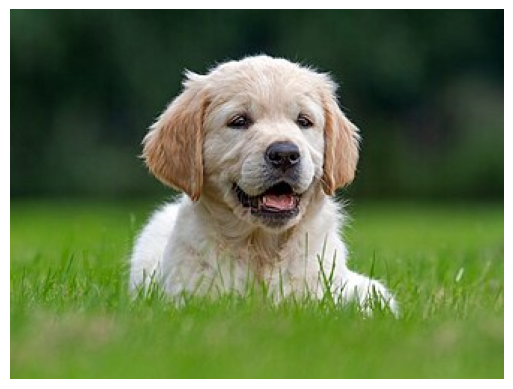

In [5]:
import matplotlib.pyplot as plt 
img = cv2.imread('images/dog1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

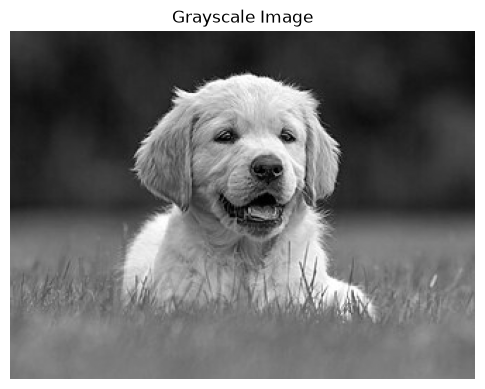

In [6]:
#Convert to greyscale 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

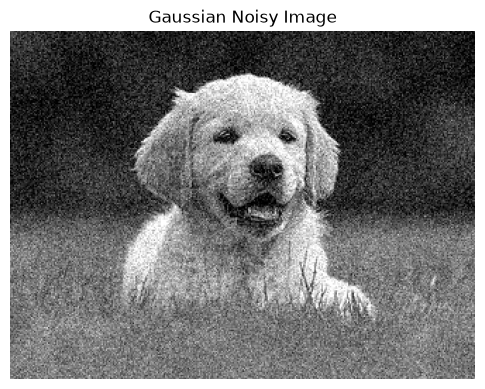

In [7]:
#Adiing Gausian Noise 
mean = 0 
sigma = 25 

#Generate Guassian noisse 
gaussian = np.random.normal(mean , sigma , gray.shape)

#Add noise 
noisy_image = gray + gaussian 

#Clip values to valid range 
noisy_image = np.clip(noisy_image , 0, 255).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noisy Image")
plt.axis("off")
plt.show()

In [15]:
rows, cols = noisy_image.shape

# Create output image
filtered_image = np.zeros((rows, cols), dtype=np.uint8)

# Apply 3x3 Averaging Filter
for i in range(1, rows-1):
    for j in range(1, cols-1):

        neighborhood = noisy_image[i-1:i+2, j-1:j+2]

        average = np.sum(neighborhood) / 9

        filtered_image[i, j] = average

/var/folders/0d/2kwkrk3j5j373ss9sbf8sd6m0000gn/T/ipykernel_20627/846620929.py:8: RuntimeWarning: overflow encountered in scalar add
  s = s+noisy_image[i+x][j+y]


(np.float64(-0.5), np.float64(329.5), np.float64(246.5), np.float64(-0.5))

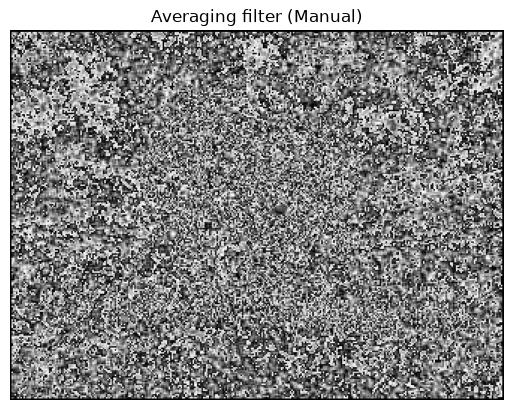

In [13]:
rows, cols = noisy_image.shape
avg2 = np.zeros((rows, cols), dtype=np.uint8)
for i in range(1, rows-1):
    for j in range(1, cols-1):
        s = 0
        for x in range(-1,2):
            for y in range(-1,2):
                s = s+noisy_image[i+x][j+y]
        avg2[i][j] = s/9
plt.imshow(avg2, cmap="gray")
plt.title("Averaging filter (Manual)")
plt.axis("off")

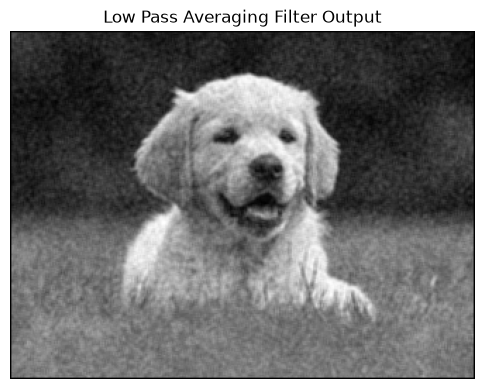

In [14]:
plt.figure(figsize=(6,6))
plt.imshow(filtered_image, cmap='gray')
plt.title("Low Pass Averaging Filter Output")
plt.axis("off")
plt.show()

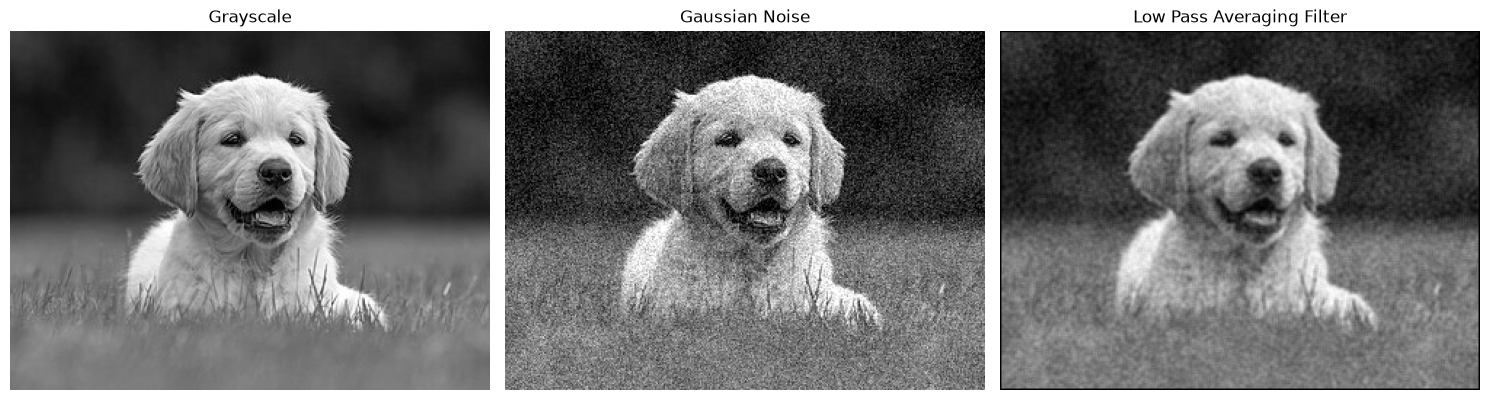

In [10]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(filtered_image, cmap='gray')
plt.title("Low Pass Averaging Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(329.5), np.float64(246.5), np.float64(-0.5))

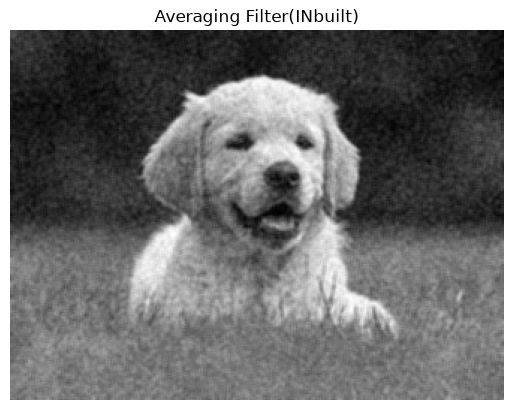

In [11]:
avg1 = cv2.blur(noisy_image,(3,3))
plt.imshow(avg1, cmap="gray")
plt.title("Averaging Filter(INbuilt)")
plt.axis("off")